In [6]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("student_performance_300.csv")

# Display basic info
print(df.head())
print(df.info())
print(df.describe())


   Age  Gender  StudyHours  Attendance ParentalEducation  InternetAccess  \
0   22  Female         1.7          80          Bachelor               0   
1   19    Male         1.8          98            Master               1   
2   23  Female         6.4          54          Bachelor               0   
3   20    Male         6.0          93            Master               1   
4   22    Male         2.9          99            Master               1   

   Extracurricular  SleepHours  PreviousGrade  FinalGrade  
0                0         5.2             64        40.0  
1                1         7.1             54        49.0  
2                1         7.5             43        46.0  
3                1         4.8             84        70.0  
4                0         4.8             99        63.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             ------

In [8]:
1.# Handle Missing Values
# -------------------------------
# Check missing values
print(df.isnull().sum())

# Fill numerical missing values with mean
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Age                  0
Gender               0
StudyHours           0
Attendance           0
ParentalEducation    0
InternetAccess       0
Extracurricular      0
SleepHours           0
PreviousGrade        0
FinalGrade           0
dtype: int64


In [21]:
# 4. Remove Duplicates
# -------------------------------
df = df.drop_duplicates()
print(df)


          Age  Gender  StudyHours  Attendance  InternetAccess  \
0    0.786526     NaN   -1.490565    0.373846               0   
1   -0.347886     NaN   -1.451606    1.628520               1   
2    1.164663     NaN    0.340500   -1.438460               0   
3    0.030251     NaN    0.184665    1.280000               1   
4    0.786526     NaN   -1.023059    1.698224               1   
..        ...     ...         ...         ...             ...   
295 -1.104161     NaN   -1.763277   -1.717277               0   
296  0.408388     NaN   -1.334730    1.489112               0   
297  0.786526     NaN   -0.088047   -1.438460               0   
298 -1.104161     NaN    0.379459   -0.392899               1   
299 -1.104161     NaN    1.002800   -1.020236               1   

     Extracurricular  SleepHours  PreviousGrade  FinalGrade  \
0                  0   -0.919289      -0.333372        40.0   
1                  1    0.400929      -0.913822        49.0   
2                  1    0.6788

In [13]:
# 3. Feature Scaling
# -------------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scale_cols = ['Age', 'StudyHours', 'Attendance', 'SleepHours', 'PreviousGrade']

df[scale_cols] = scaler.fit_transform(df[scale_cols])


In [22]:
# 4. Remove Duplicates
# -------------------------------
df = df.drop_duplicates()
print(df)


          Age  Gender  StudyHours  Attendance  InternetAccess  \
0    0.786526     NaN   -1.490565    0.373846               0   
1   -0.347886     NaN   -1.451606    1.628520               1   
2    1.164663     NaN    0.340500   -1.438460               0   
3    0.030251     NaN    0.184665    1.280000               1   
4    0.786526     NaN   -1.023059    1.698224               1   
..        ...     ...         ...         ...             ...   
295 -1.104161     NaN   -1.763277   -1.717277               0   
296  0.408388     NaN   -1.334730    1.489112               0   
297  0.786526     NaN   -0.088047   -1.438460               0   
298 -1.104161     NaN    0.379459   -0.392899               1   
299 -1.104161     NaN    1.002800   -1.020236               1   

     Extracurricular  SleepHours  PreviousGrade  FinalGrade  \
0                  0   -0.919289      -0.333372        40.0   
1                  1    0.400929      -0.913822        49.0   
2                  1    0.6788

In [26]:
# 2. Encode Categorical Data
# -------------------------------
# Convert Gender to numeric
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
print(df)

          Age  Gender  StudyHours  Attendance  InternetAccess  \
0    0.786526     NaN   -1.490565    0.373846               0   
1   -0.347886     NaN   -1.451606    1.628520               1   
2    1.164663     NaN    0.340500   -1.438460               0   
3    0.030251     NaN    0.184665    1.280000               1   
4    0.786526     NaN   -1.023059    1.698224               1   
..        ...     ...         ...         ...             ...   
295 -1.104161     NaN   -1.763277   -1.717277               0   
296  0.408388     NaN   -1.334730    1.489112               0   
297  0.786526     NaN   -0.088047   -1.438460               0   
298 -1.104161     NaN    0.379459   -0.392899               1   
299 -1.104161     NaN    1.002800   -1.020236               1   

     Extracurricular  SleepHours  PreviousGrade  FinalGrade  \
0                  0   -0.919289      -0.333372        40.0   
1                  1    0.400929      -0.913822        49.0   
2                  1    0.6788

In [29]:
# Detect & Remove Outliers using IQR Methodimport pandas as pd

df = pd.read_csv("student_performance_300.csv")

# Select only numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# IQR method
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Filter out outliers
df_clean = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) | 
                (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_clean.shape)


Original Shape: (300, 10)
After Removing Outliers: (299, 10)


In [30]:
# Detect Outliers using Z-Score Methodimport pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv("student_performance_300.csv")

# Select numeric columns
num_cols = df.select_dtypes(include=[np.number])

# Calculate Z-scores
z_scores = np.abs(stats.zscore(num_cols))

# Keep rows with Z-score < 3
df_clean = df[(z_scores < 3).all(axis=1)]

print("After Removing Outliers:", df_clean.shape)


After Removing Outliers: (300, 10)


In [31]:
# 6. Final Dataset
# -------------------------------
print("Cleaned Data Shape:", df.shape)
print(df.head())

Cleaned Data Shape: (300, 10)
   Age  Gender  StudyHours  Attendance ParentalEducation  InternetAccess  \
0   22  Female         1.7          80          Bachelor               0   
1   19    Male         1.8          98            Master               1   
2   23  Female         6.4          54          Bachelor               0   
3   20    Male         6.0          93            Master               1   
4   22    Male         2.9          99            Master               1   

   Extracurricular  SleepHours  PreviousGrade  FinalGrade  
0                0         5.2             64        40.0  
1                1         7.1             54        49.0  
2                1         7.5             43        46.0  
3                1         4.8             84        70.0  
4                0         4.8             99        63.0  


Shape: (300, 10)
   Age  Gender  StudyHours  Attendance ParentalEducation  InternetAccess  \
0   22  Female         1.7          80          Bachelor               0   
1   19    Male         1.8          98            Master               1   
2   23  Female         6.4          54          Bachelor               0   
3   20    Male         6.0          93            Master               1   
4   22    Male         2.9          99            Master               1   

   Extracurricular  SleepHours  PreviousGrade  FinalGrade  
0                0         5.2             64        40.0  
1                1         7.1             54        49.0  
2                1         7.5             43        46.0  
3                1         4.8             84        70.0  
4                0         4.8             99        63.0  

Data Types:
 Age                    int64
Gender                object
StudyHours           float64
Attendance             int64
ParentalEducation     object
Interne

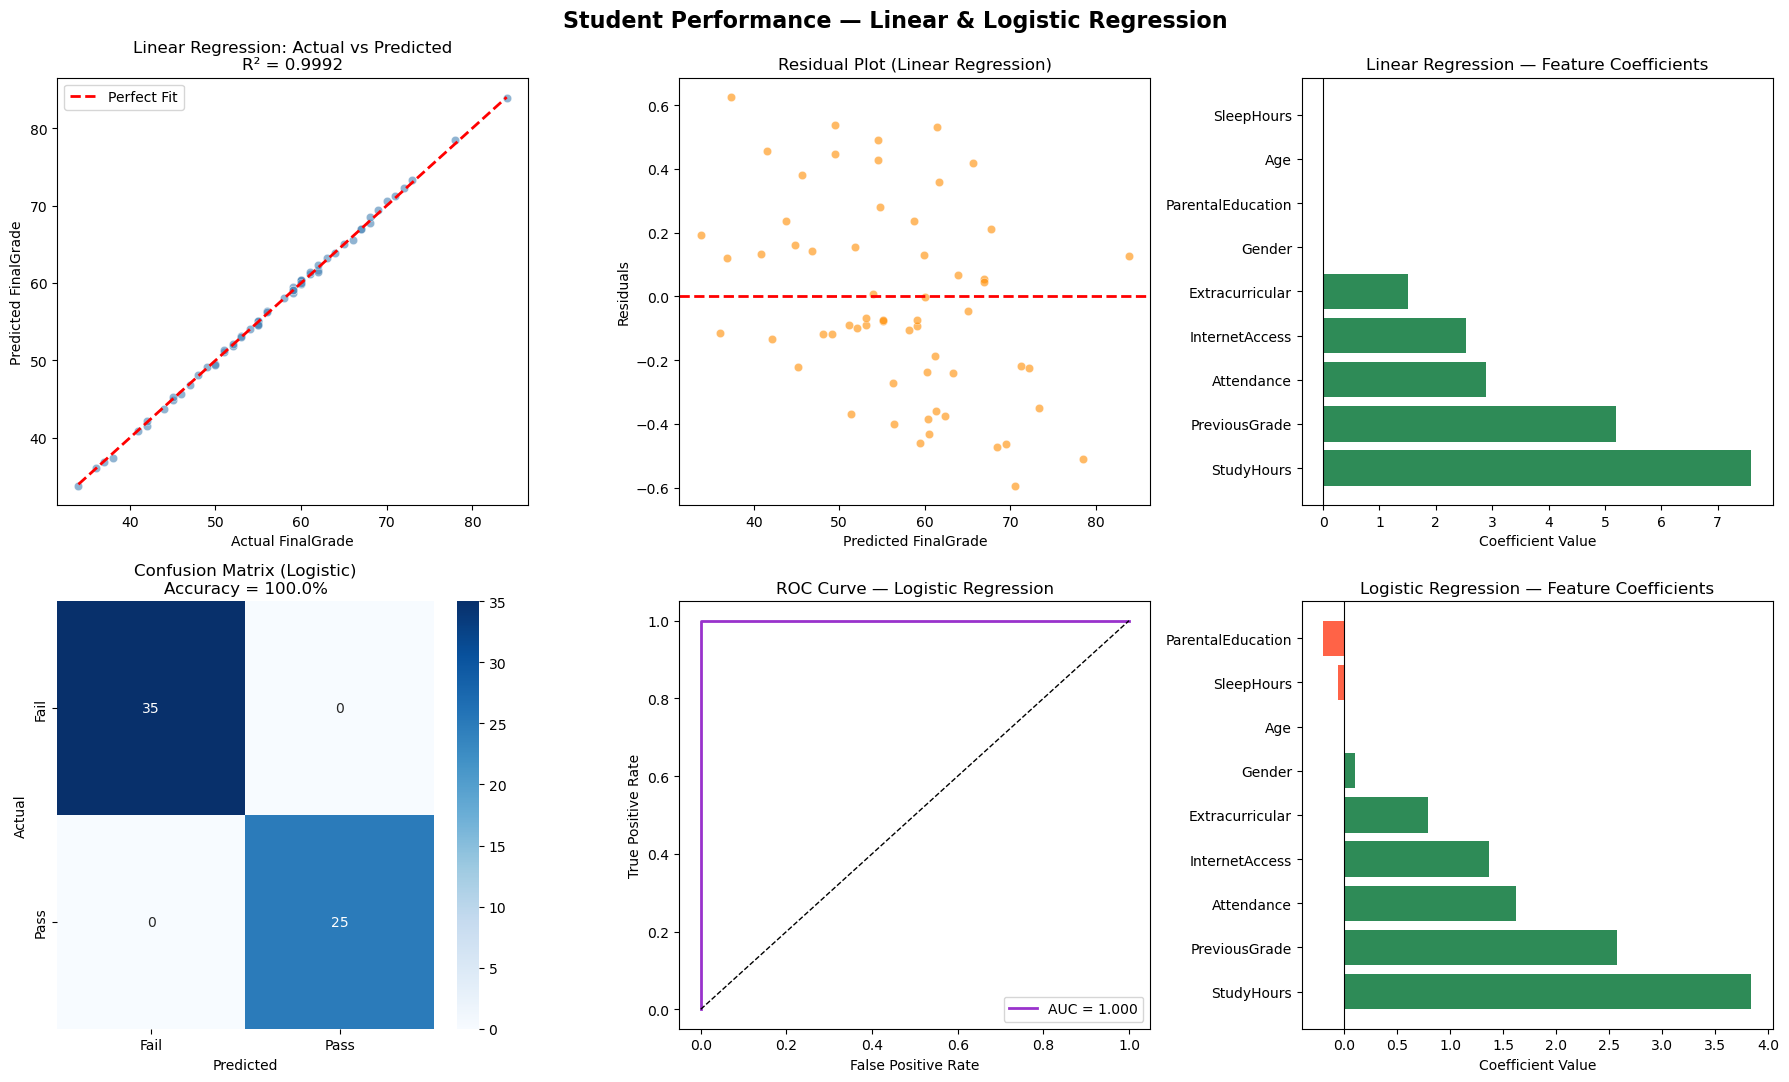


✅ Plot saved as regression_results.png


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 1. LOAD & PREPROCESS DATA
# ─────────────────────────────────────────────
df = pd.read_csv("student_performance_300.csv")
print("Shape:", df.shape)
print(df.head())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

# Encode categorical columns
le = LabelEncoder()
df["Gender"]            = le.fit_transform(df["Gender"])            # Female=0, Male=1
df["ParentalEducation"] = le.fit_transform(df["ParentalEducation"]) # HighSchool=0, Bachelor=1, Master=2

# Features & targets
feature_cols = ["Age", "Gender", "StudyHours", "Attendance",
                "ParentalEducation", "InternetAccess",
                "Extracurricular", "SleepHours", "PreviousGrade"]

X = df[feature_cols]
y_reg  = df["FinalGrade"]                        # Continuous → Linear Regression
y_cls  = (df["FinalGrade"] >= 60).astype(int)   # Binary: Pass(1) / Fail(0) → Logistic Regression

# Train-test split
X_train, X_test, yr_train, yr_test = train_test_split(X, y_reg,  test_size=0.2, random_state=42)
_,       _,      yc_train, yc_test = train_test_split(X, y_cls,  test_size=0.2, random_state=42)

# Scale features
scaler  = StandardScaler()
Xtr_sc  = scaler.fit_transform(X_train)
Xte_sc  = scaler.transform(X_test)

# ─────────────────────────────────────────────
# 2. LINEAR REGRESSION  (predict FinalGrade)
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("        LINEAR REGRESSION — Predicting FinalGrade")
print("="*55)

lr_model = LinearRegression()
lr_model.fit(Xtr_sc, yr_train)
yr_pred  = lr_model.predict(Xte_sc)

mae  = mean_absolute_error(yr_test, yr_pred)
mse  = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
r2   = r2_score(yr_test, yr_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# Coefficients
coef_df = pd.DataFrame({
    "Feature":     feature_cols,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", ascending=False)
print("\nFeature Coefficients:\n", coef_df.to_string(index=False))

# ─────────────────────────────────────────────
# 3. LOGISTIC REGRESSION  (Pass / Fail)
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("        LOGISTIC REGRESSION — Pass / Fail (≥60)")
print("="*55)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(Xtr_sc, yc_train)
yc_pred      = log_model.predict(Xte_sc)
yc_pred_prob = log_model.predict_proba(Xte_sc)[:, 1]

acc = accuracy_score(yc_test, yc_pred)
print(f"Accuracy : {acc:.4f}  ({acc*100:.1f}%)")
print("\nClassification Report:\n")
print(classification_report(yc_test, yc_pred, target_names=["Fail", "Pass"]))

# ─────────────────────────────────────────────
# 4. VISUALISATIONS
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Student Performance — Linear & Logistic Regression", fontsize=16, fontweight="bold")

# ── Plot 1: Actual vs Predicted (Linear) ──
ax = axes[0, 0]
ax.scatter(yr_test, yr_pred, alpha=0.6, color="steelblue", edgecolors="white", linewidth=0.4)
mn, mx = yr_test.min(), yr_test.max()
ax.plot([mn, mx], [mn, mx], "r--", lw=2, label="Perfect Fit")
ax.set_xlabel("Actual FinalGrade")
ax.set_ylabel("Predicted FinalGrade")
ax.set_title(f"Linear Regression: Actual vs Predicted\nR² = {r2:.4f}")
ax.legend()

# ── Plot 2: Residuals (Linear) ──
ax = axes[0, 1]
residuals = yr_test - yr_pred
ax.scatter(yr_pred, residuals, alpha=0.6, color="darkorange", edgecolors="white", linewidth=0.4)
ax.axhline(0, color="red", lw=2, ls="--")
ax.set_xlabel("Predicted FinalGrade")
ax.set_ylabel("Residuals")
ax.set_title("Residual Plot (Linear Regression)")

# ── Plot 3: Feature Coefficients (Linear) ──
ax = axes[0, 2]
colors = ["seagreen" if c > 0 else "tomato" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Linear Regression — Feature Coefficients")
ax.set_xlabel("Coefficient Value")

# ── Plot 4: Confusion Matrix (Logistic) ──
ax = axes[1, 0]
cm = confusion_matrix(yc_test, yc_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Fail", "Pass"], yticklabels=["Fail", "Pass"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (Logistic)\nAccuracy = {acc*100:.1f}%")

# ── Plot 5: ROC Curve (Logistic) ──
ax = axes[1, 1]
fpr, tpr, _ = roc_curve(yc_test, yc_pred_prob)
roc_auc     = auc(fpr, tpr)
ax.plot(fpr, tpr, color="darkorchid", lw=2, label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Logistic Regression")
ax.legend(loc="lower right")

# ── Plot 6: Feature Coefficients (Logistic) ──
ax = axes[1, 2]
log_coef = pd.DataFrame({
    "Feature":     feature_cols,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient", ascending=False)
colors2 = ["seagreen" if c > 0 else "tomato" for c in log_coef["Coefficient"]]
ax.barh(log_coef["Feature"], log_coef["Coefficient"], color=colors2)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Logistic Regression — Feature Coefficients")
ax.set_xlabel("Coefficient Value")

plt.tight_layout()
plt.savefig("regression_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Plot saved as regression_results.png")

Shape: (300, 10)
   Age  Gender  StudyHours  Attendance ParentalEducation  InternetAccess  \
0   22  Female         1.7          80          Bachelor               0   
1   19    Male         1.8          98            Master               1   
2   23  Female         6.4          54          Bachelor               0   
3   20    Male         6.0          93            Master               1   
4   22    Male         2.9          99            Master               1   

   Extracurricular  SleepHours  PreviousGrade  FinalGrade  
0                0         5.2             64        40.0  
1                1         7.1             54        49.0  
2                1         7.5             43        46.0  
3                1         4.8             84        70.0  
4                0         4.8             99        63.0  

      Finding Best K via Cross-Validation
Best K = 27  |  CV Accuracy = 85.42%

     KNN CLASSIFIER  (K=27) — Pass / Fail (≥60)
Test Accuracy : 88.33%

Classificatio

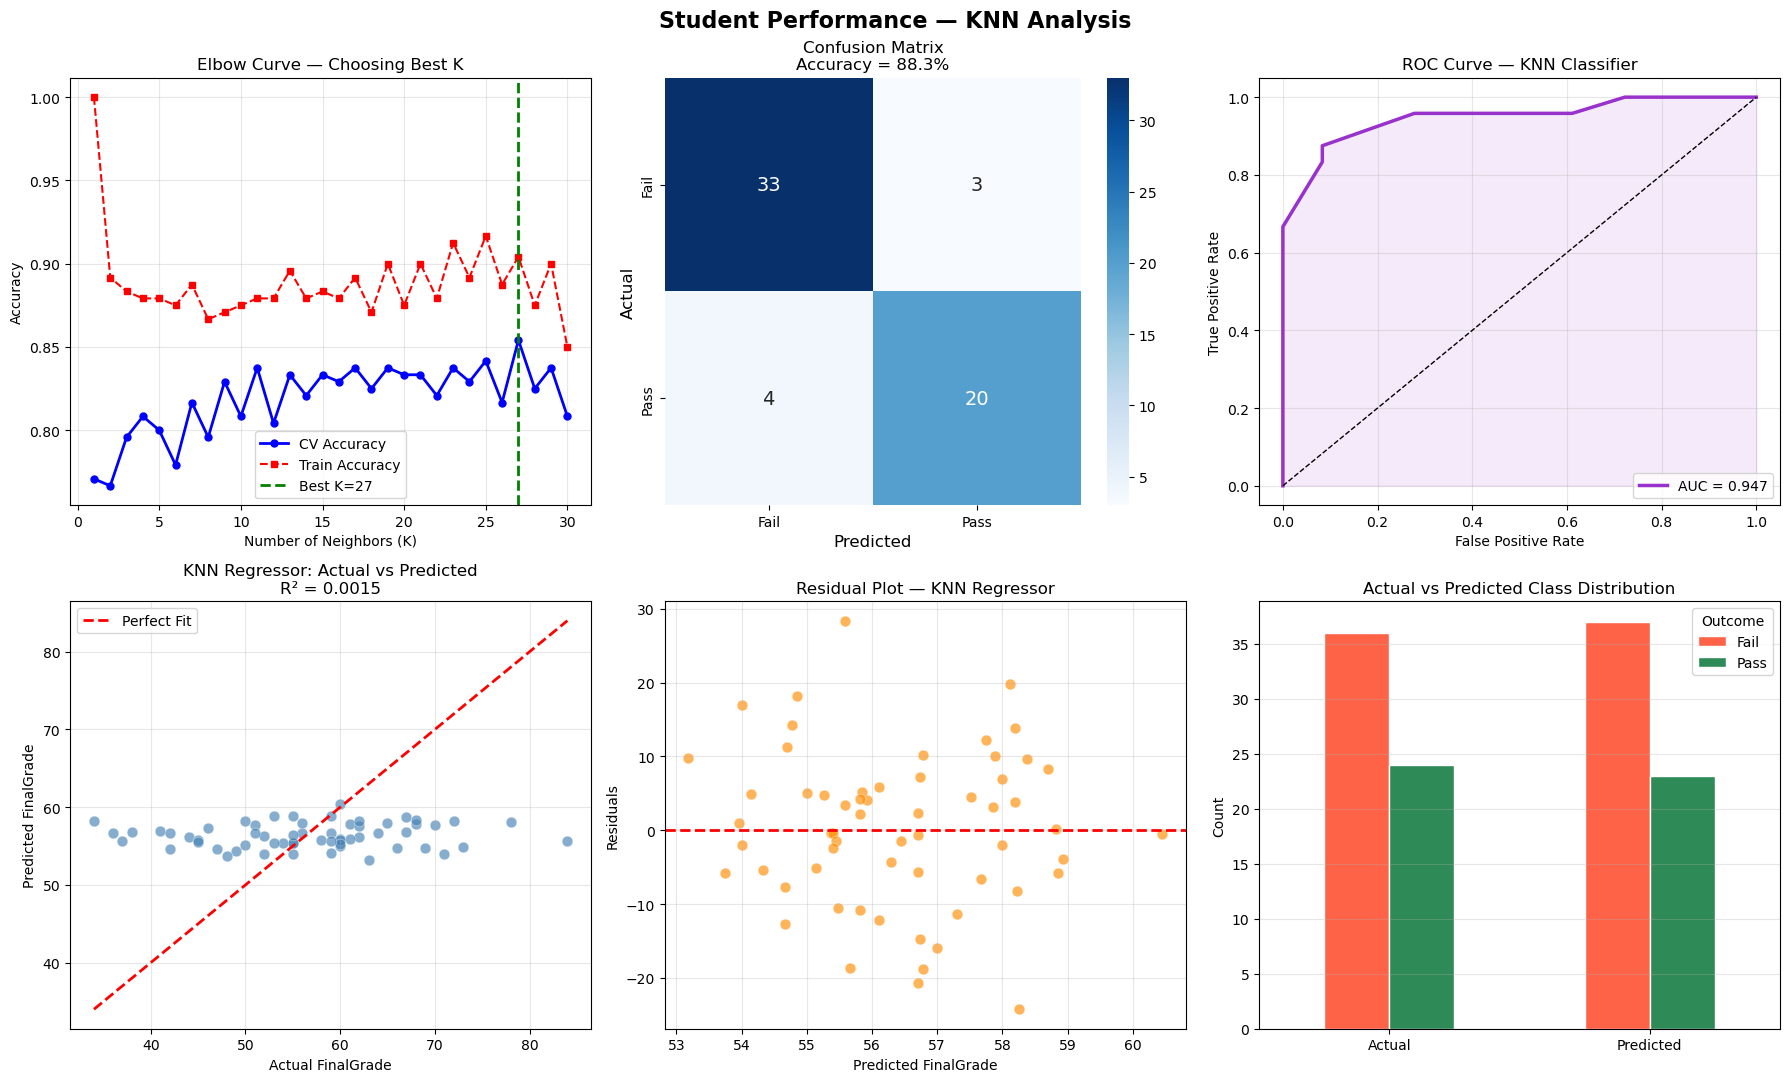


✅ Plot saved as knn_results.png

      Sample Predictions (first 10 test rows)
 Actual Grade  Predicted Grade Actual Pass/Fail Predicted Pass/Fail
         69.0             54.8             Fail                Fail
         84.0             55.6             Fail                Fail
         55.0             54.0             Fail                Fail
         60.0             60.4             Fail                Fail
         49.0             54.3             Fail                Fail
         53.0             58.9             Fail                Fail
         52.0             56.3             Fail                Fail
         56.0             56.7             Fail                Fail
         59.0             58.8             Pass                Pass
         50.0             58.2             Fail                Fail


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, mean_absolute_error, mean_squared_error, r2_score
)
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 1. LOAD & PREPROCESS DATA
# ─────────────────────────────────────────────
df = pd.read_csv("student_performance_300.csv")
print("Shape:", df.shape)
print(df.head())

# Encode categorical columns
le = LabelEncoder()
df["Gender"]            = le.fit_transform(df["Gender"])             # Female=0, Male=1
df["ParentalEducation"] = le.fit_transform(df["ParentalEducation"])  # HighSchool=0, Bachelor=1, Master=2

feature_cols = ["Age", "Gender", "StudyHours", "Attendance",
                "ParentalEducation", "InternetAccess",
                "Extracurricular", "SleepHours", "PreviousGrade"]

X      = df[feature_cols]
y_cls  = (df["FinalGrade"] >= 60).astype(int)   # Binary: Pass(1) / Fail(0)
y_reg  = df["FinalGrade"]                        # Continuous

# Train-test split
X_train, X_test, yc_train, yc_test = train_test_split(X, y_cls, test_size=0.2, random_state=42, stratify=y_cls)
_,       _,      yr_train, yr_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Scale features (very important for KNN — distance-based!)
scaler  = StandardScaler()
Xtr_sc  = scaler.fit_transform(X_train)
Xte_sc  = scaler.transform(X_test)

# ─────────────────────────────────────────────
# 2. FIND BEST K  (Elbow Method)
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("      Finding Best K via Cross-Validation")
print("="*55)

k_range      = range(1, 31)
cv_scores    = []
train_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv  = cross_val_score(knn, Xtr_sc, yc_train, cv=5, scoring="accuracy")
    cv_scores.append(cv.mean())
    knn.fit(Xtr_sc, yc_train)
    train_scores.append(knn.score(Xtr_sc, yc_train))

best_k = k_range[np.argmax(cv_scores)]
print(f"Best K = {best_k}  |  CV Accuracy = {max(cv_scores)*100:.2f}%")

# ─────────────────────────────────────────────
# 3. KNN CLASSIFIER  (Pass / Fail)
# ─────────────────────────────────────────────
print("\n" + "="*55)
print(f"     KNN CLASSIFIER  (K={best_k}) — Pass / Fail (≥60)")
print("="*55)

knn_cls = KNeighborsClassifier(n_neighbors=best_k)
knn_cls.fit(Xtr_sc, yc_train)
yc_pred      = knn_cls.predict(Xte_sc)
yc_pred_prob = knn_cls.predict_proba(Xte_sc)[:, 1]

acc = accuracy_score(yc_test, yc_pred)
print(f"Test Accuracy : {acc*100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(yc_test, yc_pred, target_names=["Fail", "Pass"]))

# ─────────────────────────────────────────────
# 4. KNN REGRESSOR  (predict FinalGrade)
# ─────────────────────────────────────────────
print("\n" + "="*55)
print(f"     KNN REGRESSOR  (K={best_k}) — Predicting FinalGrade")
print("="*55)

knn_reg  = KNeighborsRegressor(n_neighbors=best_k)
knn_reg.fit(Xtr_sc, yr_train)
yr_pred  = knn_reg.predict(Xte_sc)

mae  = mean_absolute_error(yr_test, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2   = r2_score(yr_test, yr_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# ─────────────────────────────────────────────
# 5. VISUALISATIONS  (2×3 grid)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Student Performance — KNN Analysis", fontsize=16, fontweight="bold")

# ── Plot 1: Elbow Curve ──
ax = axes[0, 0]
ax.plot(k_range, cv_scores,    "b-o", ms=5, lw=2, label="CV Accuracy")
ax.plot(k_range, train_scores, "r--s", ms=5, lw=1.5, label="Train Accuracy")
ax.axvline(best_k, color="green", ls="--", lw=2, label=f"Best K={best_k}")
ax.set_xlabel("Number of Neighbors (K)")
ax.set_ylabel("Accuracy")
ax.set_title("Elbow Curve — Choosing Best K")
ax.legend()
ax.grid(alpha=0.3)

# ── Plot 2: Confusion Matrix ──
ax = axes[0, 1]
cm = confusion_matrix(yc_test, yc_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Fail", "Pass"], yticklabels=["Fail", "Pass"],
            annot_kws={"size": 14})
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title(f"Confusion Matrix\nAccuracy = {acc*100:.1f}%")

# ── Plot 3: ROC Curve ──
ax = axes[0, 2]
fpr, tpr, _ = roc_curve(yc_test, yc_pred_prob)
roc_auc     = auc(fpr, tpr)
ax.plot(fpr, tpr, color="darkorchid", lw=2.5, label=f"AUC = {roc_auc:.3f}")
ax.fill_between(fpr, tpr, alpha=0.1, color="darkorchid")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — KNN Classifier")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

# ── Plot 4: Actual vs Predicted (Regressor) ──
ax = axes[1, 0]
ax.scatter(yr_test, yr_pred, alpha=0.65, color="steelblue",
           edgecolors="white", linewidth=0.4, s=60)
mn, mx = yr_test.min(), yr_test.max()
ax.plot([mn, mx], [mn, mx], "r--", lw=2, label="Perfect Fit")
ax.set_xlabel("Actual FinalGrade")
ax.set_ylabel("Predicted FinalGrade")
ax.set_title(f"KNN Regressor: Actual vs Predicted\nR² = {r2:.4f}")
ax.legend()
ax.grid(alpha=0.3)

# ── Plot 5: Residuals (Regressor) ──
ax = axes[1, 1]
residuals = yr_test.values - yr_pred
ax.scatter(yr_pred, residuals, alpha=0.65, color="darkorange",
           edgecolors="white", linewidth=0.4, s=60)
ax.axhline(0, color="red", lw=2, ls="--")
ax.set_xlabel("Predicted FinalGrade")
ax.set_ylabel("Residuals")
ax.set_title("Residual Plot — KNN Regressor")
ax.grid(alpha=0.3)

# ── Plot 6: Class Distribution in Predictions ──
ax = axes[1, 2]
pred_labels  = ["Fail" if p == 0 else "Pass" for p in yc_pred]
actual_labels= ["Fail" if p == 0 else "Pass" for p in yc_test]
compare_df   = pd.DataFrame({"Type": ["Actual"]*len(actual_labels) + ["Predicted"]*len(pred_labels),
                              "Label": actual_labels + pred_labels})
counts = compare_df.groupby(["Type", "Label"]).size().unstack(fill_value=0)
counts.plot(kind="bar", ax=ax, color=["tomato", "seagreen"], edgecolor="white",
            width=0.5, rot=0)
ax.set_title("Actual vs Predicted Class Distribution")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.legend(title="Outcome")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("knn_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Plot saved as knn_results.png")

# ─────────────────────────────────────────────
# 6. SAMPLE PREDICTIONS
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("      Sample Predictions (first 10 test rows)")
print("="*55)
sample = pd.DataFrame({
    "Actual Grade" : yr_test.values[:10],
    "Predicted Grade": np.round(yr_pred[:10], 1),
    "Actual Pass/Fail" : ["Pass" if v else "Fail" for v in yc_test.values[:10]],
    "Predicted Pass/Fail": ["Pass" if v else "Fail" for v in yc_pred[:10]]
})
print(sample.to_string(index=False))

       STUDENT PERFORMANCE MODEL TRAINING PIPELINE

✅ Dataset loaded  →  300 rows, 10 columns

Columns : ['Age', 'Gender', 'StudyHours', 'Attendance', 'ParentalEducation', 'InternetAccess', 'Extracurricular', 'SleepHours', 'PreviousGrade', 'FinalGrade']

Missing Values:
Age                  0
Gender               0
StudyHours           0
Attendance           0
ParentalEducation    0
InternetAccess       0
Extracurricular      0
SleepHours           0
PreviousGrade        0
FinalGrade           0

Pass/Fail Distribution:
PassFail
Fail (<60)    179
Pass (≥60)    121

📊 Train size : 240 samples
📊 Test  size : 60 samples

💾 Scaler & encoders saved  →  saved_models/

            TRAINING & EVALUATING ALL MODELS

🔄 Training  →  Logistic Regression ...
   ✔ Test Accuracy  :  96.67%
   ✔ AUC Score      :  0.9988
   ✔ CV Accuracy    :  96.67%  (5-fold)
   💾 Saved  →  saved_models/logistic_regression.pkl

🔄 Training  →  K-Nearest Neighbors ...
   ✔ Test Accuracy  :  81.67%
   ✔ AUC Score      : 

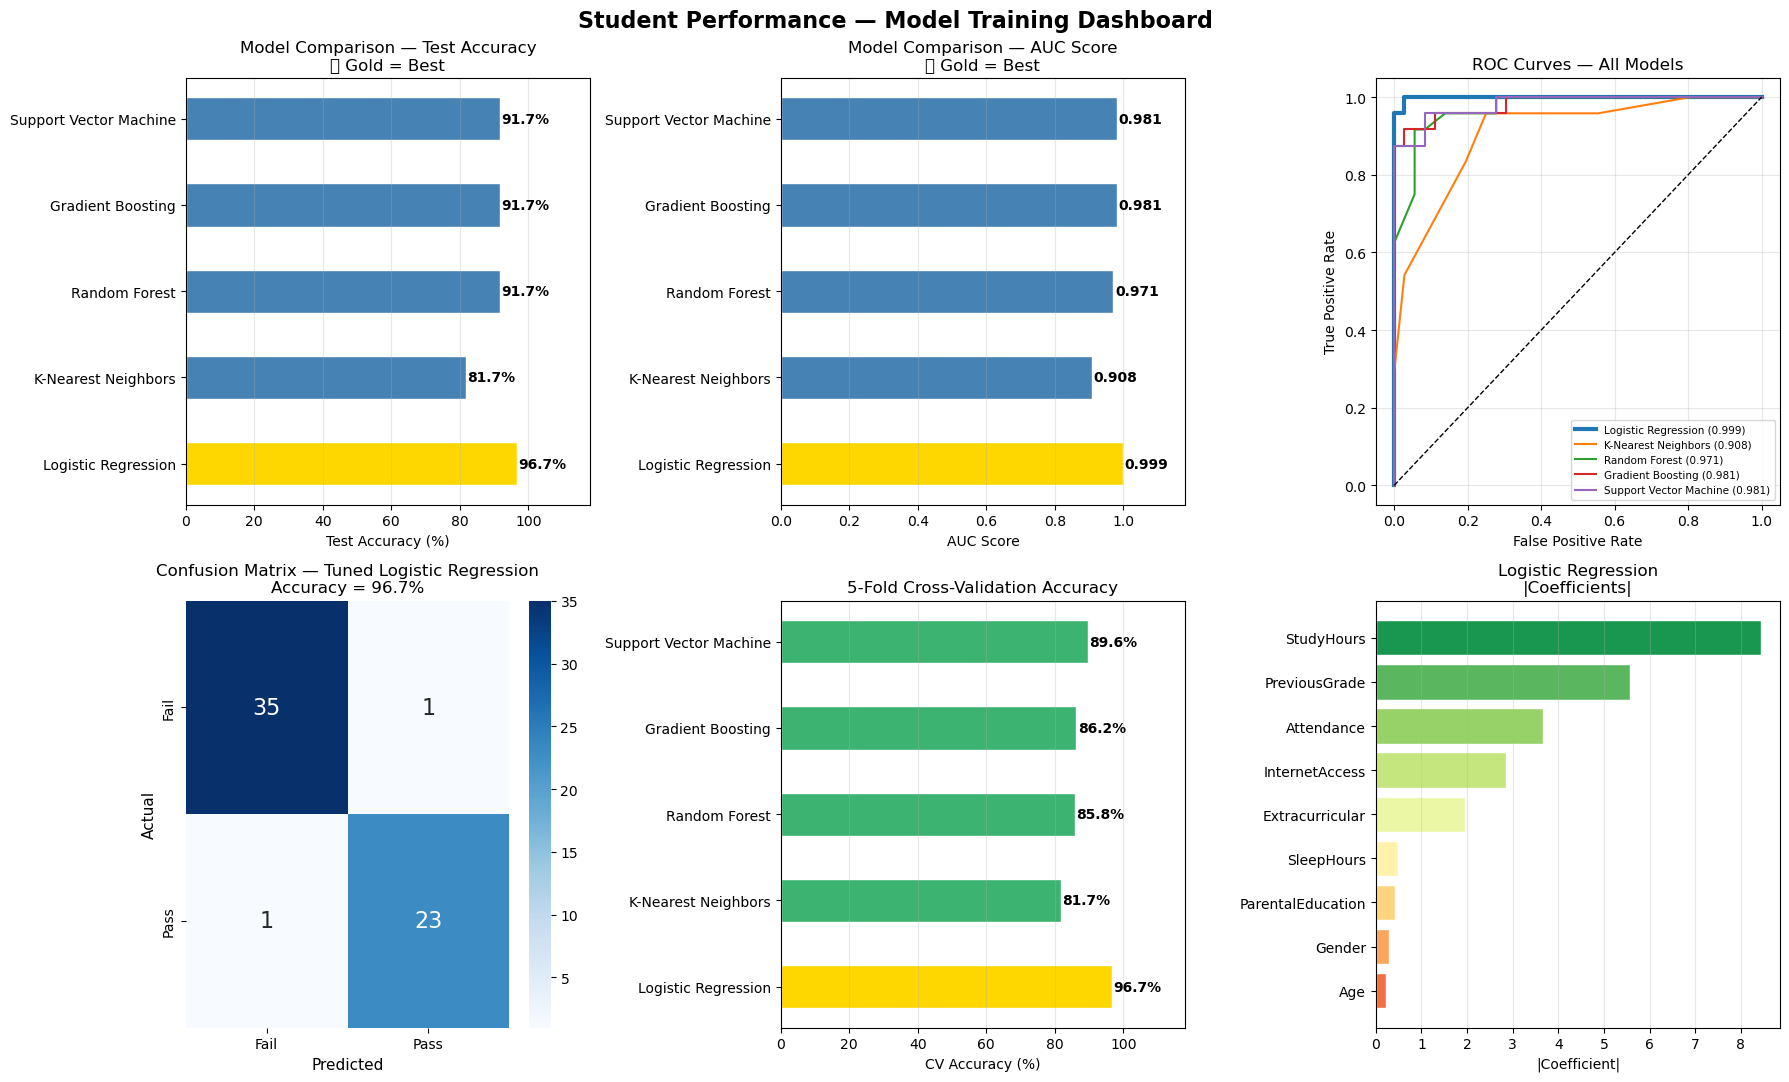


✅ Dashboard saved  →  student_training_results.png

                   MODEL SUMMARY TABLE
                 Model Test Acc %    AUC CV Acc % Best?
   Logistic Regression      96.67 0.9988    96.67     🏆
   K-Nearest Neighbors      81.67 0.9080    81.67      
         Random Forest      91.67 0.9711    85.83      
     Gradient Boosting      91.67 0.9815    86.25      
Support Vector Machine      91.67 0.9815    89.58      

   🚀  HOW TO LOAD & PREDICT WITH THE SAVED MODEL

import joblib, numpy as np

scaler = joblib.load('saved_models/scaler.pkl')
model  = joblib.load('saved_models/tuned_best_model.pkl')

# Feature order:
#   Age, Gender(0=F,1=M), StudyHours, Attendance,
#   ParentalEducation(0=HS,1=Bach,2=Master),
#   InternetAccess, Extracurricular, SleepHours, PreviousGrade

new_student = np.array([[20, 1, 7.5, 85, 1, 1, 0, 7.0, 72]])
new_scaled  = scaler.transform(new_student)

prediction  = model.predict(new_scaled)
probability = model.predict_proba(new_scaled)[:, 1]

print("Resu

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)
import warnings
warnings.filterwarnings("ignore")

os.makedirs("saved_models", exist_ok=True)

# ═══════════════════════════════════════════════════════
# 1. LOAD & PREPROCESS
# ═══════════════════════════════════════════════════════
print("=" * 62)
print("       STUDENT PERFORMANCE MODEL TRAINING PIPELINE")
print("=" * 62)

df = pd.read_csv("student_performance_300.csv")
print(f"\n✅ Dataset loaded  →  {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns : {list(df.columns)}")
print(f"\nMissing Values:\n{df.isnull().sum().to_string()}")

# Encode categorical columns
le_gender = LabelEncoder()
le_parent = LabelEncoder()
df["Gender"]            = le_gender.fit_transform(df["Gender"])           # Female=0, Male=1
df["ParentalEducation"] = le_parent.fit_transform(df["ParentalEducation"])# HighSchool=0,Bachelor=1,Master=2

# Create binary target: Pass (FinalGrade >= 60) = 1, Fail = 0
df["PassFail"] = (df["FinalGrade"] >= 60).astype(int)

print(f"\nPass/Fail Distribution:")
print(df["PassFail"].value_counts().rename({1: "Pass (≥60)", 0: "Fail (<60)"}).to_string())

feature_cols = ["Age", "Gender", "StudyHours", "Attendance",
                "ParentalEducation", "InternetAccess",
                "Extracurricular", "SleepHours", "PreviousGrade"]

X = df[feature_cols]
y = df["PassFail"]

# ═══════════════════════════════════════════════════════
# 2. TRAIN / TEST SPLIT
# ═══════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n📊 Train size : {X_train.shape[0]} samples")
print(f"📊 Test  size : {X_test.shape[0]} samples")

# ═══════════════════════════════════════════════════════
# 3. FEATURE SCALING
# ═══════════════════════════════════════════════════════
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

joblib.dump(scaler,    "saved_models/scaler.pkl")
joblib.dump(le_gender, "saved_models/le_gender.pkl")
joblib.dump(le_parent, "saved_models/le_parent.pkl")
print("\n💾 Scaler & encoders saved  →  saved_models/")

# ═══════════════════════════════════════════════════════
# 4. DEFINE & TRAIN MULTIPLE MODELS
# ═══════════════════════════════════════════════════════
models = {
    "Logistic Regression"    : LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors"    : KNeighborsClassifier(n_neighbors=7),
    "Random Forest"          : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"      : GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine" : SVC(probability=True, random_state=42),
}

print("\n" + "=" * 62)
print("            TRAINING & EVALUATING ALL MODELS")
print("=" * 62)

results = {}

for name, model in models.items():
    print(f"\n🔄 Training  →  {name} ...")
    model.fit(X_train_sc, y_train)

    y_pred      = model.predict(X_test_sc)
    y_pred_prob = model.predict_proba(X_test_sc)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    auc_ = roc_auc_score(y_test, y_pred_prob)
    cv   = cross_val_score(model, X_train_sc, y_train, cv=5, scoring="accuracy").mean()

    results[name] = {
        "model"      : model,
        "accuracy"   : acc,
        "auc"        : auc_,
        "cv_accuracy": cv,
        "y_pred"     : y_pred,
        "y_pred_prob": y_pred_prob,
    }

    print(f"   ✔ Test Accuracy  :  {acc*100:.2f}%")
    print(f"   ✔ AUC Score      :  {auc_:.4f}")
    print(f"   ✔ CV Accuracy    :  {cv*100:.2f}%  (5-fold)")

    fname = f"saved_models/{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model, fname)
    print(f"   💾 Saved  →  {fname}")

# ═══════════════════════════════════════════════════════
# 5. SELECT BEST MODEL
# ═══════════════════════════════════════════════════════
best_name  = max(results, key=lambda k: results[k]["auc"])
best       = results[best_name]
best_model = best["model"]

print("\n" + "=" * 62)
print(f"  🏆 BEST MODEL  :  {best_name}")
print(f"     Accuracy    :  {best['accuracy']*100:.2f}%")
print(f"     AUC Score   :  {best['auc']:.4f}")
print(f"     CV Accuracy :  {best['cv_accuracy']*100:.2f}%")
print("=" * 62)

joblib.dump(best_model, "saved_models/best_model.pkl")
print(f"\n💾 Best model saved  →  saved_models/best_model.pkl")

# ═══════════════════════════════════════════════════════
# 6. HYPERPARAMETER TUNING  (best model)
# ═══════════════════════════════════════════════════════
print(f"\n🔧 Hyperparameter Tuning  →  {best_name} ...")

param_grids = {
    "Logistic Regression"    : {"C": [0.01, 0.1, 1, 10], "solver": ["lbfgs", "liblinear"]},
    "K-Nearest Neighbors"    : {"n_neighbors": [3, 5, 7, 9, 11], "weights": ["uniform", "distance"]},
    "Random Forest"          : {"n_estimators": [50, 100, 200], "max_depth": [None, 5, 10]},
    "Gradient Boosting"      : {"n_estimators": [50, 100, 200], "learning_rate": [0.05, 0.1, 0.2]},
    "Support Vector Machine" : {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"]},
}

grid = GridSearchCV(
    models[best_name],
    param_grids[best_name],
    cv=5, scoring="roc_auc", n_jobs=-1, verbose=0
)
grid.fit(X_train_sc, y_train)

tuned_model = grid.best_estimator_
tuned_pred  = tuned_model.predict(X_test_sc)
tuned_prob  = tuned_model.predict_proba(X_test_sc)[:, 1]
tuned_acc   = accuracy_score(y_test, tuned_pred)
tuned_auc   = roc_auc_score(y_test, tuned_prob)

print(f"   Best Params  :  {grid.best_params_}")
print(f"   Tuned Acc    :  {tuned_acc*100:.2f}%")
print(f"   Tuned AUC    :  {tuned_auc:.4f}")

joblib.dump(tuned_model, "saved_models/tuned_best_model.pkl")
print("   💾 Tuned model saved  →  saved_models/tuned_best_model.pkl")

# ═══════════════════════════════════════════════════════
# 7. FULL CLASSIFICATION REPORT
# ═══════════════════════════════════════════════════════
print(f"\n📋 Classification Report — Tuned {best_name}:\n")
print(classification_report(y_test, tuned_pred, target_names=["Fail", "Pass"]))

# ═══════════════════════════════════════════════════════
# 8. VISUALISATIONS  —  6-panel dashboard
# ═══════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Student Performance — Model Training Dashboard",
             fontsize=16, fontweight="bold")

names      = list(results.keys())
best_color = "gold"
base_color = "steelblue"
colors     = [best_color if n == best_name else base_color for n in names]

# ── Plot 1: Model Comparison — Test Accuracy ──
ax = axes[0, 0]
accs = [results[n]["accuracy"] * 100 for n in names]
bars = ax.barh(names, accs, color=colors, edgecolor="white", height=0.5)
for bar, val in zip(bars, accs):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, 118)
ax.set_xlabel("Test Accuracy (%)")
ax.set_title("Model Comparison — Test Accuracy\n⭐ Gold = Best")
ax.grid(axis="x", alpha=0.3)

# ── Plot 2: Model Comparison — AUC ──
ax = axes[0, 1]
aucs = [results[n]["auc"] for n in names]
bars = ax.barh(names, aucs, color=colors, edgecolor="white", height=0.5)
for bar, val in zip(bars, aucs):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, 1.18)
ax.set_xlabel("AUC Score")
ax.set_title("Model Comparison — AUC Score\n⭐ Gold = Best")
ax.grid(axis="x", alpha=0.3)

# ── Plot 3: ROC Curves — All Models ──
ax = axes[0, 2]
cmap = plt.cm.get_cmap("tab10")
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res["y_pred_prob"])
    lw = 3 if name == best_name else 1.5
    ax.plot(fpr, tpr, lw=lw, color=cmap(i),
            label=f"{name} ({res['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(fontsize=7.5, loc="lower right")
ax.grid(alpha=0.3)

# ── Plot 4: Confusion Matrix — Tuned Best Model ──
ax = axes[1, 0]
cm = confusion_matrix(y_test, tuned_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Fail", "Pass"],
            yticklabels=["Fail", "Pass"],
            annot_kws={"size": 16})
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual", fontsize=11)
ax.set_title(f"Confusion Matrix — Tuned {best_name}\nAccuracy = {tuned_acc*100:.1f}%")

# ── Plot 5: 5-Fold CV Accuracy ──
ax = axes[1, 1]
cv_scores  = [results[n]["cv_accuracy"] * 100 for n in names]
cv_colors  = [best_color if n == best_name else "mediumseagreen" for n in names]
bars = ax.barh(names, cv_scores, color=cv_colors, edgecolor="white", height=0.5)
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, 118)
ax.set_xlabel("CV Accuracy (%)")
ax.set_title("5-Fold Cross-Validation Accuracy")
ax.grid(axis="x", alpha=0.3)

# ── Plot 6: Feature Importance / Coefficients ──
ax = axes[1, 2]
if hasattr(tuned_model, "feature_importances_"):
    scores       = tuned_model.feature_importances_
    xlabel_text  = "Importance"
    title_suffix = "Feature Importances"
elif hasattr(tuned_model, "coef_"):
    scores       = np.abs(tuned_model.coef_[0])
    xlabel_text  = "|Coefficient|"
    title_suffix = "|Coefficients|"
else:
    scores       = np.ones(len(feature_cols))
    xlabel_text  = "Weight"
    title_suffix = "Feature Weights"

feat_df = pd.DataFrame({"Feature": feature_cols, "Score": scores}).sort_values("Score")
bar_c   = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_df)))
ax.barh(feat_df["Feature"], feat_df["Score"], color=bar_c, edgecolor="white")
ax.set_title(f"{best_name}\n{title_suffix}")
ax.set_xlabel(xlabel_text)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("student_training_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Dashboard saved  →  student_training_results.png")

# ═══════════════════════════════════════════════════════
# 9. SUMMARY TABLE
# ═══════════════════════════════════════════════════════
print("\n" + "=" * 62)
print("                   MODEL SUMMARY TABLE")
print("=" * 62)
summary = pd.DataFrame([{
    "Model"       : n,
    "Test Acc %"  : f"{results[n]['accuracy']*100:.2f}",
    "AUC"         : f"{results[n]['auc']:.4f}",
    "CV Acc %"    : f"{results[n]['cv_accuracy']*100:.2f}",
    "Best?"       : "🏆" if n == best_name else ""
} for n in names])
print(summary.to_string(index=False))

# ═══════════════════════════════════════════════════════
# 10. HOW TO LOAD & PREDICT
# ═══════════════════════════════════════════════════════
print("\n" + "=" * 62)
print("   🚀  HOW TO LOAD & PREDICT WITH THE SAVED MODEL")
print("=" * 62)
print("""
import joblib, numpy as np

scaler = joblib.load('saved_models/scaler.pkl')
model  = joblib.load('saved_models/tuned_best_model.pkl')

# Feature order:
#   Age, Gender(0=F,1=M), StudyHours, Attendance,
#   ParentalEducation(0=HS,1=Bach,2=Master),
#   InternetAccess, Extracurricular, SleepHours, PreviousGrade

new_student = np.array([[20, 1, 7.5, 85, 1, 1, 0, 7.0, 72]])
new_scaled  = scaler.transform(new_student)

prediction  = model.predict(new_scaled)
probability = model.predict_proba(new_scaled)[:, 1]

print("Result      :", "Pass ✅" if prediction[0] == 1 else "Fail ❌")
print("Pass Prob   :", f"{probability[0]*100:.1f}%")
""")